In [ ]:
import sys, importlib.metadata as md
print("Python:", sys.version.split()[0])
print("Executable:", sys.executable)
for pkg in ["flwr", "fedml", "syft", "opacus", "torch", "torchvision", "numpy", "ray", "flgo"]:
    try:
        print(f"{pkg}: {md.version(pkg)}")
    except Exception:
        print(f"{pkg}: не установлен")

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from collections import OrderedDict

from flwr.client import ClientApp, NumPyClient
from flwr.server import ServerApp, ServerConfig, ServerAppComponents
from flwr.server.strategy import FedAvg
from flwr.simulation import run_simulation
from flwr.common import Context, ndarrays_to_parameters

NUM_CLIENTS = 3
NUM_ROUNDS = 5
LOCAL_EPOCHS = 1
BATCH_SIZE = 32
N_TRAIN_PER_CLIENT = 4000
DEVICE = torch.device("cpu")

torch.manual_seed(0)
np.random.seed(0)
print("OK, готово")

In [16]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_set = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_set = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

def make_client_loaders(client_id):
    g = torch.Generator().manual_seed(42)
    all_idx = torch.randperm(len(train_set), generator=g).tolist()
    per = len(all_idx) // NUM_CLIENTS
    idx = all_idx[client_id * per : (client_id + 1) * per]
    if N_TRAIN_PER_CLIENT is not None:
        idx = idx[:N_TRAIN_PER_CLIENT]
    train_loader = DataLoader(Subset(train_set, idx), batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=256)
    return train_loader, test_loader

print("Клиент 0 получил", len(make_client_loaders(0)[0].dataset), "картинок")

Клиент 0 получил 4000 картинок


In [17]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(32 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

print("Модель готова, параметров:", sum(p.numel() for p in Net().parameters()))

Модель готова, параметров: 105866


In [18]:
def train(net, loader, epochs):
    net.train()
    opt = torch.optim.Adam(net.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            loss = criterion(net(x), y)
            loss.backward()
            opt.step()

def test(net, loader):
    net.eval()
    criterion = nn.CrossEntropyLoss()
    loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = net(x)
            loss += criterion(out, y).item() * y.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
    return loss / total, correct / total

print("Функции train и test готовы")

Функции train и test готовы


In [19]:
def get_parameters(net):
    return [val.cpu().numpy() for val in net.state_dict().values()]

def set_parameters(net, parameters):
    params_dict = zip(net.state_dict().keys(), parameters)
    state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
    net.load_state_dict(state_dict, strict=True)

print("Мост PyTorch <-> Flower готов")

Мост PyTorch <-> Flower готов


In [20]:
class FlowerClient(NumPyClient):
    def __init__(self, net, train_loader, test_loader):
        self.net = net
        self.train_loader = train_loader
        self.test_loader = test_loader

    def fit(self, parameters, config):
        set_parameters(self.net, parameters)
        train(self.net, self.train_loader, epochs=LOCAL_EPOCHS)
        return get_parameters(self.net), len(self.train_loader.dataset), {}

    def evaluate(self, parameters, config):
        set_parameters(self.net, parameters)
        loss, acc = test(self.net, self.test_loader)
        return loss, len(self.test_loader.dataset), {"accuracy": acc}

def client_fn(context: Context):
    cid = context.node_config["partition-id"]
    net = Net().to(DEVICE)
    train_loader, test_loader = make_client_loaders(cid)
    return FlowerClient(net, train_loader, test_loader).to_client()

client_app = ClientApp(client_fn=client_fn)

print("Клиент Flower готов")

Клиент Flower готов


In [21]:
round_accuracy = []

def weighted_average(metrics):
    total = sum(n for n, _ in metrics)
    acc = sum(n * m["accuracy"] for n, m in metrics) / total
    round_accuracy.append(acc)
    return {"accuracy": acc}

def server_fn(context: Context):
    initial = ndarrays_to_parameters(get_parameters(Net()))
    strategy = FedAvg(
        fraction_fit=1.0,
        fraction_evaluate=1.0,
        min_available_clients=NUM_CLIENTS,
        evaluate_metrics_aggregation_fn=weighted_average,
        initial_parameters=initial,
    )
    return ServerAppComponents(strategy=strategy, config=ServerConfig(num_rounds=NUM_ROUNDS))

server_app = ServerApp(server_fn=server_fn)

print("Сервер и стратегия FedAvg готовы")

Сервер и стратегия FedAvg готовы


In [22]:
import numpy as np

# создаём 3 клиентов напрямую, без Ray
clients = []
for cid in range(NUM_CLIENTS):
    net = Net().to(DEVICE)
    train_loader, test_loader = make_client_loaders(cid)
    clients.append(FlowerClient(net, train_loader, test_loader))

# стартовые веса глобальной модели (одинаковые для всех)
global_params = get_parameters(Net().to(DEVICE))

round_accuracy = []

for rnd in range(1, NUM_ROUNDS + 1):
    # 1. каждый клиент учится на своих данных, стартуя с глобальных весов
    results = []
    for client in clients:
        new_params, n, _ = client.fit(global_params, {})
        results.append((new_params, n))

    # 2. FedAvg: взвешенное усреднение весов по числу примеров
    total = sum(n for _, n in results)
    global_params = [
        sum(w[i] * n for w, n in results) / total
        for i in range(len(results[0][0]))
    ]

    # 3. проверяем новую глобальную модель на всех клиентах
    total_examples, acc_sum = 0, 0.0
    for client in clients:
        loss, n, metrics = client.evaluate(global_params, {})
        acc_sum += metrics["accuracy"] * n
        total_examples += n
    acc = acc_sum / total_examples
    round_accuracy.append(acc)
    print(f"Раунд {rnd}: accuracy = {acc * 100:.2f}%")

print("\nОбучение завершено!")

Раунд 1: accuracy = 89.28%
Раунд 2: accuracy = 96.01%
Раунд 3: accuracy = 97.13%
Раунд 4: accuracy = 97.73%
Раунд 5: accuracy = 97.61%

Обучение завершено!


In [23]:
from opacus import PrivacyEngine

NOISE_MULTIPLIER = 1.1   # уровень гауссова шума (больше -> приватнее, но ниже accuracy)
MAX_GRAD_NORM   = 1.0    # порог клиппинга градиента каждого примера (DP-SGD)
DELTA           = 1e-5   # δ: допустимая вероятность нарушения гарантии

def get_weights(net):
    return [p.detach().cpu().numpy() for p in net.parameters()]

def set_weights(net, weights):
    with torch.no_grad():
        for p, w in zip(net.parameters(), weights):
            p.copy_(torch.tensor(w))

class DPClient:
    def __init__(self, net, train_loader, test_loader):
        opt = torch.optim.Adam(net.parameters(), lr=0.001)
        self.privacy_engine = PrivacyEngine()
        self.net, self.opt, self.loader = self.privacy_engine.make_private(
            module=net, optimizer=opt, data_loader=train_loader,
            noise_multiplier=NOISE_MULTIPLIER, max_grad_norm=MAX_GRAD_NORM,
        )
        self.test_loader = test_loader
        self.n = len(train_loader.dataset)

    def fit(self, global_weights):
        set_weights(self.net, global_weights)
        self.net.train()
        criterion = nn.CrossEntropyLoss()
        for _ in range(LOCAL_EPOCHS):
            for x, y in self.loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                self.opt.zero_grad()
                loss = criterion(self.net(x), y)
                loss.backward()
                self.opt.step()
        return get_weights(self.net), self.n

# создаём 3 клиентов с DP, стартовые веса — как в ячейке 7
dp_clients = []
for cid in range(NUM_CLIENTS):
    net = Net().to(DEVICE)
    train_loader, test_loader = make_client_loaders(cid)
    dp_clients.append(DPClient(net, train_loader, test_loader))

global_params = get_weights(Net().to(DEVICE))
dp_round_accuracy = []

for rnd in range(1, NUM_ROUNDS + 1):
    results = []
    for client in dp_clients:
        new_params, n = client.fit(global_params)
        results.append((new_params, n))

    total = sum(n for _, n in results)
    global_params = [sum(w[i] * n for w, n in results) / total
                     for i in range(len(results[0][0]))]

    eval_net = Net().to(DEVICE); set_weights(eval_net, global_params); eval_net.eval()
    correct, total_examples = 0, 0
    with torch.no_grad():
        for client in dp_clients:
            for x, y in client.test_loader:
                out = eval_net(x)
                correct += (out.argmax(1) == y).sum().item()
                total_examples += y.size(0)
    acc = correct / total_examples
    dp_round_accuracy.append(acc)
    print(f"[DP] Раунд {rnd}: accuracy = {acc * 100:.2f}%")

eps = dp_clients[0].privacy_engine.get_epsilon(DELTA)
print(f"\nИтоговый бюджет приватности: ε ≈ {eps:.2f} при δ = {DELTA}")

C:\Users\nak\AppData\Local\Temp\ipykernel_29584\3140702252.py:35: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


[DP] Раунд 1: accuracy = 44.29%
[DP] Раунд 2: accuracy = 56.79%
[DP] Раунд 3: accuracy = 65.16%
[DP] Раунд 4: accuracy = 68.95%
[DP] Раунд 5: accuracy = 73.28%

Итоговый бюджет приватности: ε ≈ 0.95 при δ = 1e-05


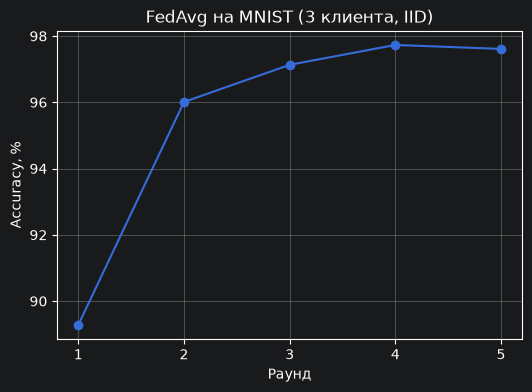

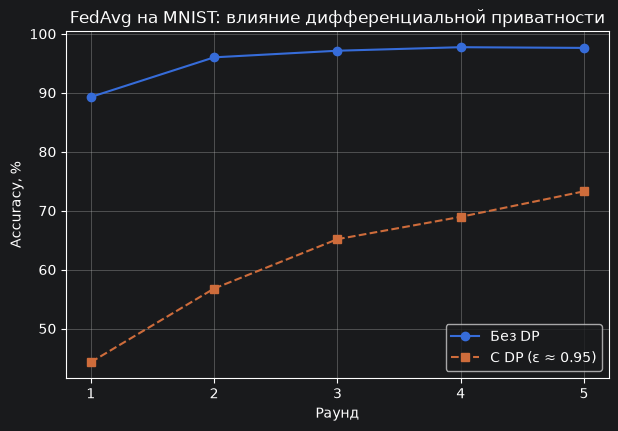

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(round_accuracy) + 1),
         [a * 100 for a in round_accuracy], marker="o")
plt.xlabel("Раунд")
plt.ylabel("Accuracy, %")
plt.title("FedAvg на MNIST (3 клиента, IID)")
plt.xticks(range(1, NUM_ROUNDS + 1))
plt.grid(True)
plt.savefig("flower_accuracy.png", dpi=120, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 4.5))
plt.plot(range(1, len(round_accuracy) + 1),
         [a * 100 for a in round_accuracy], marker="o", label="Без DP")
plt.plot(range(1, len(dp_round_accuracy) + 1),
         [a * 100 for a in dp_round_accuracy], marker="s", linestyle="--",
         label=f"С DP (ε ≈ {eps:.2f})")
plt.xlabel("Раунд")
plt.ylabel("Accuracy, %")
plt.title("FedAvg на MNIST: влияние дифференциальной приватности")
plt.xticks(range(1, NUM_ROUNDS + 1))
plt.legend()
plt.grid(True)
plt.savefig("dp_comparison.png", dpi=120, bbox_inches="tight")
plt.show()